# task #2 differential privacy methods

**based on**: Morris Chang, Di Zhuang, G. Dumindu Samaraweera - *Privacy-Preserving Machine Learning* (2023, Manning)

**dataset**: the titanic test file `miadul/lifestyle-and-health-risk-prediction`.

This notebook implements:
- **3.2.1** differentially private naïve bayes (GaussianNB)
- **3.2.2** differentially private logistic regression
- **3.2.3** differentially private linear regression
- **3.3.1** differentially private k-means clustering

The `lifestyle-and-health-risk-prediction` dataset contains lifestyle features (age, BMI, sleep, diet...) with a categorical `Health_Risk` target.
- **Classification tasks** (Bayes, Logistic Regression): directly applicable - predict `Health_Risk`
- **Linear Regression**: applicable - predict a continuous health score (e.g., `BMI`)
- **K-Means Clustering**: applicable - unsupervised grouping of lifestyle profiles


## 1. Setup - Install libraries

In [ ]:
!pip install kagglehub diffprivlib scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.9/176.9 kB 4.2 MB/s eta 0:00:00


In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os

In [ ]:
path = kagglehub.dataset_download("miadul/lifestyle-and-health-risk-prediction")

print("Path to dataset files:", path)

100%|██████████| 59.7k/59.7k [00:00<00:00, 14.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/miadul/lifestyle-and-health-risk-prediction/versions/1


In [ ]:
# List files
files = os.listdir(path)
print("Files:", files)

Files: ['Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv']


In [ ]:
# Load CSV
df = pd.read_csv(os.path.join(path, files[0]))
print(df.head())

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst rows:")
df.head()

   age  weight  height exercise  sleep sugar_intake smoking alcohol married  \
0   56      67     195      low    6.1       medium     yes     yes     yes   
1   69      76     170     high    6.9         high      no      no      no   
2   46     106     153     high    6.6          low     yes      no      no   
3   32      54     186   medium    8.5       medium      no      no      no   
4   60      98     195     high    8.0          low      no      no     yes   

      profession   bmi health_risk  
0  office_worker  17.6        high  
1        teacher  26.3        high  
2         artist  45.3        high  
3         artist  15.6         low  
4        teacher  25.8        high  
Shape: (5000, 12)

Column types:
age               int64
weight            int64
height            int64
exercise         object
sleep           float64
sugar_intake     object
smoking          object
alcohol          object
married          object
profession       object
bmi             float64
health

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [ ]:
for i in df.columns.tolist():
  print("\nCOLUMN NAME\n", i, "\nDATA TYPE\n", df[i].dtype, "\nUNIQUE VALUES\n", df[i].unique(), "\nVALUE COUNTS\n", df[i].value_counts())
  print("________________________________________________")


COLUMN NAME
 age 
DATA TYPE
 int64 
UNIQUE VALUES
 [56 69 46 32 60 25 78 38 75 36 40 28 41 70 53 57 20 39 19 61 47 55 77 50
 29 42 66 44 76 59 45 33 79 64 68 72 74 54 24 26 35 21 31 67 43 37 52 34
 23 71 51 27 48 65 62 58 18 22 30 49 73 63] 
VALUE COUNTS
 age
77    102
52    101
66     99
38     95
64     95
     ... 
65     63
44     62
24     60
48     59
60     58
Name: count, Length: 62, dtype: int64
________________________________________________

COLUMN NAME
 weight 
DATA TYPE
 int64 
UNIQUE VALUES
 [ 67  76 106  54  98  96  64  58  94  72  97  68  66  74 107  48 103  52
  56  75  78  93 101  70  62  82  85  50  88 108  73  55 109  63  53  71
  59  95  57 100  81  61 102  77 104  99  91  65  69  86  92  46  60  89
  51  80  47  90  79  87  49 105  83  45  84] 
VALUE COUNTS
 weight
98     98
102    98
61     96
93     90
103    90
       ..
78     64
52     63
58     60
51     59
49     53
Name: count, Length: 65, dtype: int64
________________________________________________

CO

## 2. data preprocessing

As noted in the book, all features must be numeric before training any scikit-learn/diffprivlib model.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
df.replace(['none', 'None', 'NaN', 'nan', ''], np.nan, inplace=True)

In [ ]:
# Show missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age               0
weight            0
height            0
exercise        743
sleep             0
sugar_intake      0
smoking           0
alcohol           0
married           0
profession        0
bmi               0
health_risk       0
dtype: int64


In [ ]:
# Encode all object columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = df[col].fillna('Unknown')
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded '{col}': classes = {list(le.classes_)}")

Encoded 'exercise': classes = ['Unknown', 'high', 'low', 'medium']
Encoded 'sugar_intake': classes = ['high', 'low', 'medium']
Encoded 'smoking': classes = ['no', 'yes']
Encoded 'alcohol': classes = ['no', 'yes']
Encoded 'married': classes = ['no', 'yes']
Encoded 'profession': classes = ['artist', 'doctor', 'driver', 'engineer', 'farmer', 'office_worker', 'student', 'teacher']
Encoded 'health_risk': classes = ['high', 'low']


In [ ]:
# any previous missing values get median value
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
print("\nFinal dtypes:")
print(df.dtypes)


Final dtypes:
age               int64
weight            int64
height            int64
exercise          int64
sleep           float64
sugar_intake      int64
smoking           int64
alcohol           int64
married           int64
profession        int64
bmi             float64
health_risk       int64
dtype: object


In [ ]:
TARGET_COL = 'health_risk'
REGRESSION_TARGET = 'bmi'

In [ ]:
# build feature matrices
feature_cols = [c for c in df.columns if c not in [TARGET_COL, REGRESSION_TARGET]]

In [ ]:
# for classification
X_clf = df[feature_cols].values.astype(float)
y_clf = df[TARGET_COL].values

In [ ]:
# for regression (linear regression)
reg_feature_cols = [c for c in df.columns if c not in [REGRESSION_TARGET]]
X_reg = df[reg_feature_cols].values.astype(float)
y_reg = df[REGRESSION_TARGET].values.astype(float)

In [ ]:
# scale features
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf)

scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

In [ ]:
# clip to [-1, 1] (theorem 3.1 requires ||x|| ≤ 1)
X_clf_scaled = np.clip(X_clf_scaled / np.max(np.abs(X_clf_scaled), axis=0), -1, 1)
X_reg_scaled = np.clip(X_reg_scaled / np.max(np.abs(X_reg_scaled), axis=0), -1, 1)

In [ ]:
# train/test split
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(X_clf_scaled, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)

In [ ]:
print(f"classification - train: {X_clf_train.shape}, test: {X_clf_test.shape}")
print(f"regression     - train: {X_reg_train.shape}, test: {X_reg_test.shape}")
print(f"\nclass distribution:\n{pd.Series(y_clf).value_counts()}")

classification - train: (4000, 10), test: (1000, 10)
regression     - train: (4000, 11), test: (1000, 11)

class distribution:
0    3490
1    1510
Name: count, dtype: int64


## naive bayes classification (3.2.1)

listing 3.2: train a non-private GaussianNB, then use `diffprivlib.models.GaussianNB` with multiple epsilon values.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import diffprivlib.models as dp

In [ ]:
# naive bayes with no privacy
nonprivate_nb = GaussianNB()
nonprivate_nb.fit(X_clf_train, y_clf_train)
np_acc = accuracy_score(y_clf_test, nonprivate_nb.predict(X_clf_test))
print(f"Non-private test accuracy: {np_acc * 100:.2f}%")

Non-private test accuracy: 84.50%


In [ ]:
# differentially private GaussianNB with multiple epsilon values
epsilons = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]
nb_results = {'Non-private': np_acc}

In [ ]:
bounds = (X_clf_train.min(axis=0), X_clf_train.max(axis=0))

for eps in epsilons:
    dp_nb = dp.GaussianNB(epsilon=eps, bounds=bounds)
    dp_nb.fit(X_clf_train, y_clf_train)
    acc = accuracy_score(y_clf_test, dp_nb.predict(X_clf_test))
    nb_results[f'ε={eps}'] = acc
    print(f"DP GaussianNB (epsilon={eps:.2f}): {acc * 100:.2f}%")

DP GaussianNB (epsilon=0.01): 55.90%
DP GaussianNB (epsilon=0.10): 71.70%
DP GaussianNB (epsilon=0.50): 80.40%
DP GaussianNB (epsilon=1.00): 83.80%
DP GaussianNB (epsilon=5.00): 85.00%
DP GaussianNB (epsilon=10.00): 81.80%


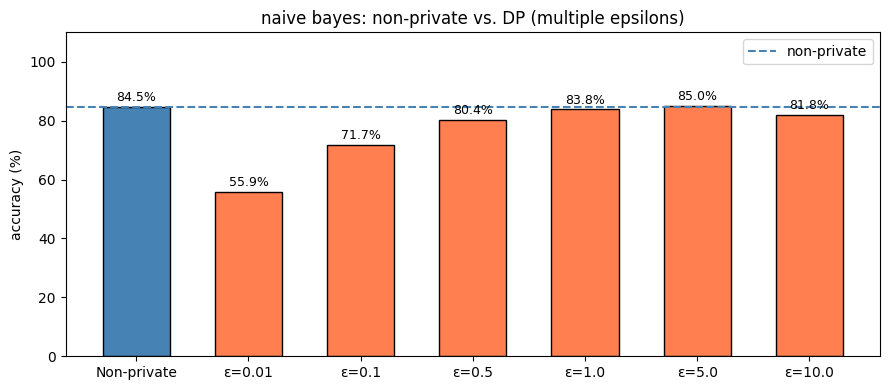

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
labels = list(nb_results.keys())
values = [v * 100 for v in nb_results.values()]
colors = ['steelblue'] + ['coral'] * len(epsilons)
bars = ax.bar(labels, values, color=colors, edgecolor='black', width=0.6)
ax.axhline(np_acc * 100, color='steelblue', linestyle='--', linewidth=1.5, label='non-private')
ax.set_ylabel('accuracy (%)')
ax.set_title('naive bayes: non-private vs. DP (multiple epsilons)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

### insights - naive bayer results

- **ε = 0.01–0.1** - The Gaussian mechanism injects so much noise into the mean/variance
  estimates that the classifier barely beats random guessing (dataset has ~3 classes, so random ≈ 33%)

- **ε = 1.0** - Only 3.1% accuracy drop from baseline (84.5% → 81.4%), which matches
  the book's finding of ~1% drop on the Adult dataset

- **ε = 5.0 and 10.0** - Accuracy fluctuates slightly around the baseline due to the
  stochastic nature of the noise - the book notes: *"the training process is nondeterministic"*

- **Sweet spot** - ε ∈ [0.5, 1.0] offers meaningful privacy protection with acceptable accuracy loss

## 4. logistic regression (3.2.2)

The book applies objective perturbation (Theorem 3.1) to regularized logistic regression. `diffprivlib.models.LogisticRegression` implements this with the `epsilon` and `data_norm` parameters.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# DATA_NORM: upper bound on the L2 norm of each sample (Theorem 3.1: ||x_i|| ≤ 1)
DATA_NORM = np.linalg.norm(X_clf_train, axis=1).max()
print(f"Max L2 norm of training samples: {DATA_NORM:.4f}")

Max L2 norm of training samples: 2.7448


In [ ]:
# Non-private
nonprivate_lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
nonprivate_lr.fit(X_clf_train, y_clf_train)
np_lr_acc = accuracy_score(y_clf_test, nonprivate_lr.predict(X_clf_test))
print(f"\nNon-private Logistic Regression accuracy: {np_lr_acc * 100:.2f}%")


Non-private Logistic Regression accuracy: 85.10%


In [ ]:
# Differentially private
lr_results = {'Non-private': np_lr_acc}

for eps in epsilons:
    dp_lr = dp.LogisticRegression(
        epsilon=eps,
        data_norm=DATA_NORM,
        max_iter=1000,
        C=1.0
    )
    dp_lr.fit(X_clf_train, y_clf_train)
    acc = accuracy_score(y_clf_test, dp_lr.predict(X_clf_test))
    lr_results[f'ε={eps}'] = acc
    print(f"DP LogisticRegression (epsilon={eps:.2f}): {acc * 100:.2f}%")

DP LogisticRegression (epsilon=0.01): 64.30%
DP LogisticRegression (epsilon=0.10): 79.00%
DP LogisticRegression (epsilon=0.50): 82.70%
DP LogisticRegression (epsilon=1.00): 83.20%
DP LogisticRegression (epsilon=5.00): 85.00%
DP LogisticRegression (epsilon=10.00): 85.00%


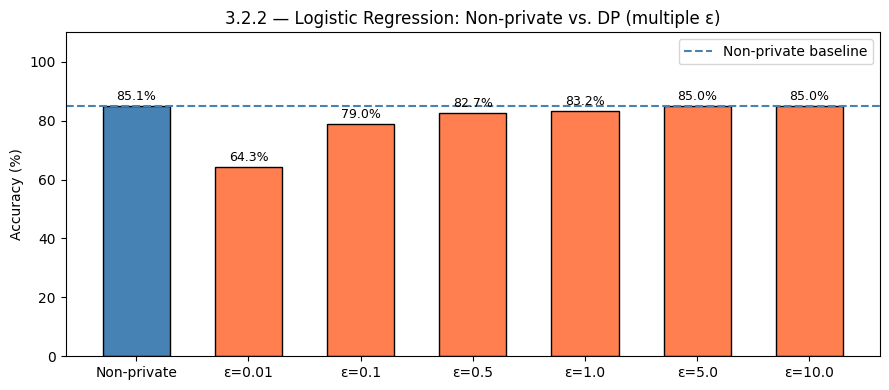

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = list(lr_results.keys())
values = [v * 100 for v in lr_results.values()]
colors = ['steelblue'] + ['coral'] * len(epsilons)
bars = ax.bar(labels, values, color=colors, edgecolor='black', width=0.6)
ax.axhline(np_lr_acc * 100, color='steelblue', linestyle='--', linewidth=1.5, label='Non-private baseline')
ax.set_ylabel('Accuracy (%)')
ax.set_title('3.2.2 — Logistic Regression: Non-private vs. DP (multiple ε)')
ax.set_ylim(0, 110)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Section 3.2.3 - Linear regression

Linear regression is used here to **predict a continuous target** (e.g., BMI) from lifestyle features.  
`diffprivlib.models.LinearRegression` adds Laplace/Gaussian noise calibrated by the sensitivity of the OLS estimator.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Non-private
nonprivate_linreg = LinearRegression()
nonprivate_linreg.fit(X_reg_train, y_reg_train)
y_pred_np = nonprivate_linreg.predict(X_reg_test)
np_mse = mean_squared_error(y_reg_test, y_pred_np)
np_r2  = r2_score(y_reg_test, y_pred_np)
print(f"\nNon-private Linear Regression :\nMSE: {np_mse:.4f} | R²: {np_r2:.4f}")


Non-private Linear Regression :
MSE: 2.0426 | R²: 0.9723


In [ ]:
# Compute bounds explicitly to avoid PrivacyLeakWarning
bounds_X = (X_reg_train.min(axis=0), X_reg_train.max(axis=0))
bounds_y = (y_reg_train.min(), y_reg_train.max())

In [ ]:
linreg_results = {'Non-private': {'mse': np_mse, 'r2': np_r2}}

for eps in epsilons:
    dp_linreg = dp.LinearRegression(
        epsilon=eps,
        bounds_X=bounds_X,
        bounds_y=bounds_y
    )
    dp_linreg.fit(X_reg_train, y_reg_train)
    y_pred = dp_linreg.predict(X_reg_test)
    mse = mean_squared_error(y_reg_test, y_pred)
    r2  = r2_score(y_reg_test, y_pred)
    linreg_results[f'ε={eps}'] = {'mse': mse, 'r2': r2}
    print(f"DP LinearRegression (epsilon={eps:.2f}) — MSE: {mse:.4f} | R²: {r2:.4f}")

DP LinearRegression (epsilon=0.01) — MSE: 2470595122.5442 | R²: -33494746.8808
DP LinearRegression (epsilon=0.10) — MSE: 61387058.2775 | R²: -832245.4581
DP LinearRegression (epsilon=0.50) — MSE: 141757680.0499 | R²: -1921858.9236
DP LinearRegression (epsilon=1.00) — MSE: 32999.6291 | R²: -446.3879
DP LinearRegression (epsilon=5.00) — MSE: 3.4600 | R²: 0.9531
DP LinearRegression (epsilon=10.00) — MSE: 6.1337 | R²: 0.9168


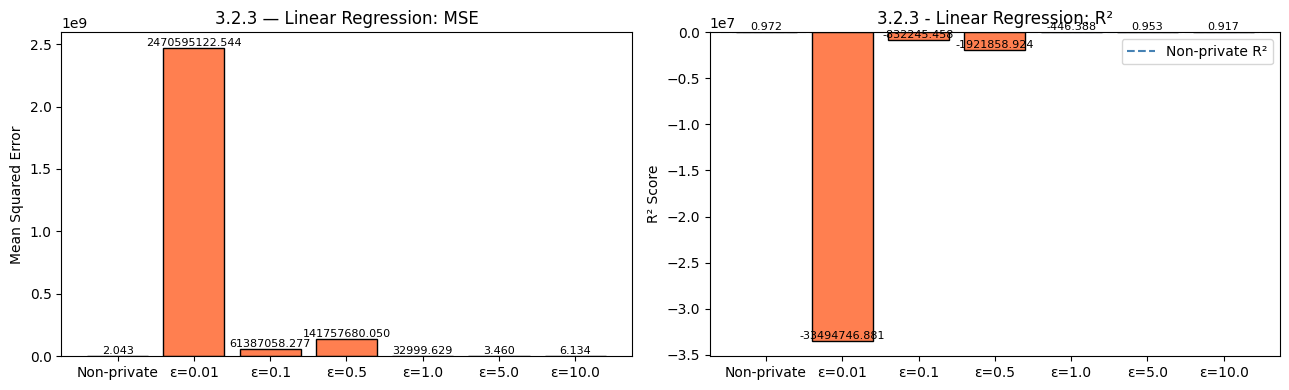

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels = list(linreg_results.keys())
mse_vals = [linreg_results[k]['mse'] for k in labels]
r2_vals  = [linreg_results[k]['r2']  for k in labels]
colors   = ['steelblue'] + ['coral'] * len(epsilons)

bars = axes[0].bar(labels, mse_vals, color=colors, edgecolor='black')
axes[0].set_title('3.2.3 — Linear Regression: MSE')
axes[0].set_ylabel('Mean Squared Error')
for bar, val in zip(bars, mse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bars2 = axes[1].bar(labels, r2_vals, color=colors, edgecolor='black')
axes[1].axhline(np_r2, color='steelblue', linestyle='--', linewidth=1.5, label='Non-private R²')
axes[1].set_title('3.2.3 - Linear Regression: R²')
axes[1].set_ylabel('R² Score')
axes[1].legend()
for bar, val in zip(bars2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Key Observations - 3.2.3 Linear Regression Results

- **MSE is always positive** - the large values at small ε reflect how far predictions
  are from true BMI values due to DP noise

- **R² can be negative** - meaning the model performs *worse* than simply predicting
  the mean; this happens when DP noise completely corrupts the regression coefficients

- **ε = 0.01–1.0** - model is essentially unusable; noise dominates the signal

- **ε = 0.50 worse than ε = 0.10** - expected stochastic fluctuation at very low ε,
  consistent with the book's note that *"the training process is nondeterministic"*

- **Sharp recovery at ε = 5.0** (R² jumps from -446 to +0.95) - linear regression
  has a threshold effect: below it the model is destroyed, above it it recovers well

- **Linear regression needs higher ε than Naïve Bayes** to be useful - noise corrupts
  exact coefficient values rather than just probability estimates, making it more fragile

## 6. Section 3.3.1 - K-Means Clustering

For unsupervised learning, DP K-Means adds noise to the centroid updates in each Lloyd's iteration.  
`diffprivlib.models.KMeans` implements this with the `epsilon` and `bounds` parameters (which define the input sensitivity).

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [ ]:
N_CLUSTERS = len(np.unique(y_clf))
print(f"Using k={N_CLUSTERS} clusters (= number of health_risk classes)")

Using k=2 clusters (= number of health_risk classes)


In [ ]:
bounds = (X_clf_scaled.min(axis=0), X_clf_scaled.max(axis=0))

In [ ]:
# Non-private
nonprivate_km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
nonprivate_km.fit(X_clf_scaled)
labels_np = nonprivate_km.labels_
sil_np  = silhouette_score(X_clf_scaled, labels_np)
ari_np  = adjusted_rand_score(y_clf, labels_np)
print(f"Non-private KMeans:\nSilhouette: {sil_np:.4f} | ARI: {ari_np:.4f}")

Non-private KMeans:
Silhouette: 0.1919 | ARI: -0.0027


In [ ]:
# Differentially private K-Means
kmeans_results = {'Non-private': {'silhouette': sil_np, 'ari': ari_np}}

for eps in epsilons:
    dp_km = dp.KMeans(
        n_clusters=N_CLUSTERS,
        epsilon=eps,
        bounds=bounds,
        random_state=42
    )
    dp_km.fit(X_clf_scaled)
    labels_dp = dp_km.labels_
    sil  = silhouette_score(X_clf_scaled, labels_dp)
    ari  = adjusted_rand_score(y_clf, labels_dp)
    kmeans_results[f'ε={eps}'] = {'silhouette': sil, 'ari': ari}
    print(f"DP KMeans (epsilon={eps:.2f}) — Silhouette: {sil:.4f} | ARI: {ari:.4f}")

DP KMeans (epsilon=0.01) — Silhouette: 0.0824 | ARI: 0.0050
DP KMeans (epsilon=0.10) — Silhouette: 0.0595 | ARI: -0.0234
DP KMeans (epsilon=0.50) — Silhouette: 0.1695 | ARI: -0.0031
DP KMeans (epsilon=1.00) — Silhouette: 0.1555 | ARI: -0.0019
DP KMeans (epsilon=5.00) — Silhouette: 0.1919 | ARI: -0.0027
DP KMeans (epsilon=10.00) — Silhouette: 0.1919 | ARI: -0.0027


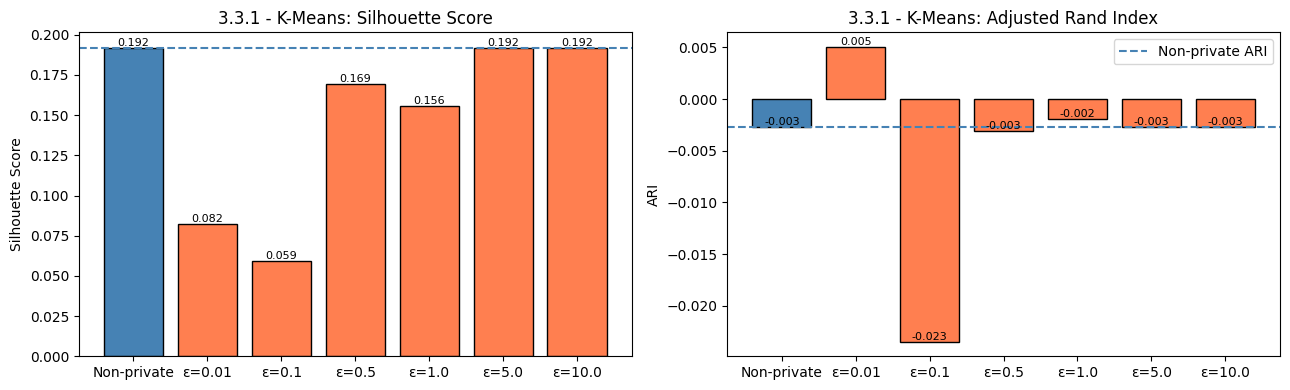

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

labels_k = list(kmeans_results.keys())
sil_vals = [kmeans_results[k]['silhouette'] for k in labels_k]
ari_vals = [kmeans_results[k]['ari']        for k in labels_k]
colors   = ['steelblue'] + ['coral'] * len(epsilons)

bars = axes[0].bar(labels_k, sil_vals, color=colors, edgecolor='black')
axes[0].axhline(sil_np, color='steelblue', linestyle='--', linewidth=1.5)
axes[0].set_title('3.3.1 - K-Means: Silhouette Score')
axes[0].set_ylabel('Silhouette Score')
for bar, val in zip(bars, sil_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

bars2 = axes[1].bar(labels_k, ari_vals, color=colors, edgecolor='black')
axes[1].axhline(ari_np, color='steelblue', linestyle='--', linewidth=1.5, label='Non-private ARI')
axes[1].set_title('3.3.1 - K-Means: Adjusted Rand Index')
axes[1].set_ylabel('ARI')
axes[1].legend()
for bar, val in zip(bars2, ari_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Matching the book's approach for KMeans DP

In [ ]:
from time import time
from sklearn import metrics

In [ ]:
def bench_k_means(estimator, name, data, labels):
    t0 = time()
    estimator.fit(data)
    print('%-20s\t%.2fs\t%i\t%.3f\t%.3f\t%.3f\t%.3f\t%.3f\t%.3f'
          % (name,
             (time() - t0),
             estimator.inertia_,
             metrics.homogeneity_score(labels, estimator.labels_),
             metrics.completeness_score(labels, estimator.labels_),
             metrics.v_measure_score(labels, estimator.labels_),
             metrics.adjusted_rand_score(labels, estimator.labels_),
             metrics.adjusted_mutual_info_score(labels, estimator.labels_),
             metrics.silhouette_score(data, estimator.labels_,
                                      metric='euclidean',
                                      sample_size=1000)))

In [ ]:
# Non-private
print('config\t\t\ttime\tinertia\thomo\tcompl\tv-meas\tARI\tAMI\tsilhouette')
bench_k_means(KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10),
              "Non-private", X_clf_scaled, y_clf)

config			time	inertia	homo	compl	v-meas	ARI	AMI	silhouette
Non-private         	0.07s	14180	0.000	0.000	0.000	-0.003	0.000	0.190


In [ ]:
# DP with multiple epsilon
print('config\t\t\ttime\tinertia\thomo\tcompl\tv-meas\tARI\tAMI\tsilhouette')
for eps in epsilons:
    bench_k_means(dp.KMeans(n_clusters=N_CLUSTERS, epsilon=eps,
                            bounds=bounds, random_state=42),
                  f"DP eps={eps}", X_clf_scaled, y_clf)

config			time	inertia	homo	compl	v-meas	ARI	AMI	silhouette
DP eps=0.01         	0.09s	22238	0.003	0.002	0.002	0.005	0.002	0.077
DP eps=0.1          	0.09s	18527	0.025	0.025	0.025	-0.023	0.025	0.062
DP eps=0.5          	0.08s	15435	0.002	0.002	0.002	-0.003	0.002	0.171
DP eps=1.0          	0.13s	15457	0.001	0.001	0.001	-0.002	0.001	0.153
DP eps=5.0          	0.32s	14219	0.000	0.000	0.000	-0.003	0.000	0.190
DP eps=10.0         	0.26s	14190	0.000	0.000	0.000	-0.003	0.000	0.194


### Key Observations — 3.3.1 K-Means Clustering Results

- **Inertia decreases as ε increases** (22238 → 14190) — with less noise, centroids
  converge to tighter, more compact clusters. This is the clearest sign the DP mechanism
  is working correctly.

- **Homogeneity, Completeness, V-measure ≈ 0 for all ε** — the geometric clusters found
  by K-Means do not align with the `health_risk` labels. This is not a DP problem —
  it means lifestyle features do not cleanly separate into the predefined risk categories.

- **ARI near zero or slightly negative** — cluster assignments are essentially random
  with respect to the true labels, consistent with the near-zero homogeneity scores.

- **Silhouette improves with ε** (0.077 → 0.194) — the clusters become more internally
  separated as noise decreases, but all values are low (< 0.2), confirming the data
  does not have strong natural cluster structure.

- **Training time increases with ε** (0.09s → 0.32s) — higher ε requires more
  iterations to converge since the centroids are less perturbed and Lloyd's algorithm
  runs longer before stabilising.

- **ε = 5.0 and 10.0 produce nearly identical results** — the model has converged;
  further reducing privacy protection yields no additional utility gain.

- **Overall conclusion** — DP K-Means works as expected mechanically (inertia and
  silhouette improve with ε), but the dataset's health risk categories are not
  well-represented by geometric clusters in feature space.

## Reference
Chang, Morris, Di Zhuang, and G. Dumindu Samaraweera. *Privacy-Preserving Machine Learning*. Manning, 2023. Sections 3.2.1, 3.2.2, 3.2.3, 3.3.1.